In [1]:
%pip install alpaca-trade-api python-dotenv pandas matplotlib ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 4.1 MB/s  0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.3-cp312-cp312-linux_x86_64.whl size=15772 sha256=8b92015316ab2bc9457993b9cc5d5cb9c68afb1a51694b9b7719164eb109b3b7
  Stored in directory: /home/67bb2c08-b3d3-4398-a24b-4043e6d05117/.cache/pip/wheels/ba/bd/3f/f043e8f634db9c90ae128d631f43ae9990eef01274a63291f9
  Created wheel for websockets: filename=websockets-10.4-cp312-cp312-linux_x86_64.whl size=98714 sha256=f5dae7bcfc228e8dd2d052710870d8f3e0d6322a00bc8f81463851b3a5c13dc2
  Stored in directory: /home/67bb2c08-b3d3-4398-a24b-4043e

# User
where can i restart the kernal

# Assistant
To restart the kernel in a Jupyter Notebook, you have several options:

## Menu Options:
1. **Kernel Menu**: Go to `Kernel` → `Restart` in the top menu bar
2. **Kernel Menu with Clear**: Go to `Kernel` → `Restart & Clear Output` to restart and clear all cell outputs
3. **Kernel Menu with Run All**: Go to `Kernel` → `Restart & Run All` to restart and automatically run all cells

## Keyboard Shortcuts:
- **Ctrl + M + .** (Windows/Linux) or **Cmd + M + .** (Mac) - Restart kernel
- **0, 0** (press zero twice) - Restart kernel (when in command mode)

## Toolbar Button:
- Look for the **circular arrow icon** (↻) in the toolbar, which is the restart button

## When to Restart:
You might want to restart the kernel when:
- Variables are cluttered and you want a fresh start
- You've made changes to imported modules
- The kernel becomes unresponsive
- You want to test your code from a clean state
- Memory usage is getting too high

**Note**: Restarting the kernel will clear all variables from memory, so you'll need to re-run your cells to restore your workspace state.

In [2]:
import alpaca_trade_api as tradeapi
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from dotenv import load_dotenv

print("All imports worked.")


All imports worked.


In [3]:
from getpass import getpass
from pathlib import Path

api_key = getpass("Paste your Alpaca API key: ")
secret_key = getpass("Paste your Alpaca secret key: ")

Path(".env").write_text(
    f'APCA_API_KEY_ID="{api_key}"\n'
    f'APCA_API_SECRET_KEY="{secret_key}"\n'
)

print(".env created successfully.")

Paste your Alpaca API key:  ········
Paste your Alpaca secret key:  ········


.env created successfully.


In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("APCA_API_KEY_ID")
SECRET_KEY = os.getenv("APCA_API_SECRET_KEY")

print("API key found:", API_KEY is not None)
print("Secret key found:", SECRET_KEY is not None)


API key found: True
Secret key found: True


In [5]:
import alpaca_trade_api as tradeapi

PAPER_URL = "https://paper-api.alpaca.markets"

api = tradeapi.REST(
    key_id=API_KEY,
    secret_key=SECRET_KEY,
    base_url=PAPER_URL,
    api_version="v2"
)

account = api.get_account()

print("Account status:", account.status)
print("Cash:", account.cash)
print("Buying power:", account.buying_power)

Account status: ACTIVE
Cash: 100000
Buying power: 400000


In [6]:
from datetime import datetime, timedelta, timezone

SYMBOL = "TQQQ"

end_date = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=30)

bars = api.get_bars(
    symbol=SYMBOL,
    timeframe=tradeapi.TimeFrame.Day,
    start=start_date.isoformat(),
    end=end_date.isoformat(),
    adjustment="raw",
    feed="iex"
)

historical_data = bars.df

display(historical_data.tail())

,close,high,low,trade_count,open,volume,vwap
timestamp,,,,,,,
2026-06-18 04:00:00+00:00,82.975,83.550,80.65,6110,81.970,827406,82.254070
2026-06-22 04:00:00+00:00,82.670,85.095,81.41,5400,83.870,652664,82.912951
2026-06-23 04:00:00+00:00,74.380,77.730,73.95,6635,75.130,911743,75.629790
2026-06-24 04:00:00+00:00,73.350,76.150,71.35,4911,74.790,577243,73.779923
2026-06-25 04:00:00+00:00,74.790,78.230,71.62,10487,77.945,1302898,74.555147


In [7]:
ohlcv_data = historical_data[
    ["open", "high", "low", "close", "volume"]
].copy()

display(ohlcv_data.tail(10))

,open,high,low,close,volume
timestamp,,,,,
2026-06-11 04:00:00+00:00,70.765,76.595,69.600,76.100,1334534
2026-06-12 04:00:00+00:00,76.320,78.345,74.300,77.510,1049786
2026-06-15 04:00:00+00:00,82.910,85.010,82.655,84.700,581940
2026-06-16 04:00:00+00:00,84.165,84.800,79.900,80.000,734255
2026-06-17 04:00:00+00:00,81.640,81.805,76.940,77.590,741806
2026-06-18 04:00:00+00:00,81.970,83.550,80.650,82.975,827406
2026-06-22 04:00:00+00:00,83.870,85.095,81.410,82.670,652664
2026-06-23 04:00:00+00:00,75.130,77.730,73.950,74.380,911743
2026-06-24 04:00:00+00:00,74.790,76.150,71.350,73.350,577243


In [9]:
quote = api.get_latest_quote("TQQQ")

bid = quote.bid_price
ask = quote.ask_price

print("Symbol: TQQQ")
print("Bid price:", bid)
print("Bid size:", quote.bid_size)
print("Ask price:", ask)
print("Ask size:", quote.ask_size)
print("Timestamp:", quote.timestamp)

if bid > 0 and ask > 0:
    spread = ask - bid
    print("Spread:", spread)
else:
    print("Spread unavailable because the bid or ask is missing.")

Symbol: TQQQ
Bid price: 75.15
Bid size: 100
Ask price: 0
Ask size: 0
Timestamp: 2026-06-25 16:00:22.860328218-04:00
Spread unavailable because the bid or ask is missing.


In [10]:
%%writefile data_connector.py

import os
from datetime import datetime, timedelta, timezone

import alpaca_trade_api as tradeapi
from dotenv import load_dotenv


class AlpacaDataConnector:
    """
    Connects to Alpaca's paper-trading and market-data APIs.
    """

    def __init__(self):
        # Load variables from the .env file
        load_dotenv()

        self.api_key = os.getenv("APCA_API_KEY_ID")
        self.secret_key = os.getenv("APCA_API_SECRET_KEY")
        self.paper_url = "https://paper-api.alpaca.markets"

        if not self.api_key or not self.secret_key:
            raise ValueError(
                "Alpaca API credentials were not found."
            )

        # REST connection used for account information,
        # historical data, and latest quotes
        self.api = tradeapi.REST(
            key_id=self.api_key,
            secret_key=self.secret_key,
            base_url=self.paper_url,
            api_version="v2"
        )

    def get_account(self):
        """Return paper-trading account information."""
        return self.api.get_account()

    def get_historical_data(self, symbol="TQQQ", days=30):
        """
        Download daily OHLCV data for a symbol.
        """
        end_date = datetime.now(timezone.utc)
        start_date = end_date - timedelta(days=days)

        bars = self.api.get_bars(
            symbol=symbol,
            timeframe=tradeapi.TimeFrame.Day,
            start=start_date.isoformat(),
            end=end_date.isoformat(),
            adjustment="raw",
            feed="iex"
        )

        return bars.df[
            ["open", "high", "low", "close", "volume"]
        ].copy()

    def get_latest_quote(self, symbol="TQQQ"):
        """Return the latest available bid/ask quote."""
        return self.api.get_latest_quote(symbol)

    def create_quote_stream(self):
        """Create a real-time IEX quote stream."""
        return tradeapi.Stream(
            key_id=self.api_key,
            secret_key=self.secret_key,
            base_url=self.paper_url,
            data_feed="iex"
        )

Writing data_connector.py


In [11]:
from data_connector import AlpacaDataConnector

connector = AlpacaDataConnector()

print("Connector created successfully.")

Connector created successfully.


In [12]:
account = connector.get_account()

print("Account status:", account.status)
print("Cash:", account.cash)
print("Buying power:", account.buying_power)

Account status: ACTIVE
Cash: 100000
Buying power: 400000


In [13]:
tqqq_data = connector.get_historical_data(
    symbol="TQQQ",
    days=30
)

display(tqqq_data.tail(10))

,open,high,low,close,volume
timestamp,,,,,
2026-06-11 04:00:00+00:00,70.765,76.595,69.600,76.100,1334534
2026-06-12 04:00:00+00:00,76.320,78.345,74.300,77.510,1049786
2026-06-15 04:00:00+00:00,82.910,85.010,82.655,84.700,581940
2026-06-16 04:00:00+00:00,84.165,84.800,79.900,80.000,734255
2026-06-17 04:00:00+00:00,81.640,81.805,76.940,77.590,741806
2026-06-18 04:00:00+00:00,81.970,83.550,80.650,82.975,827406
2026-06-22 04:00:00+00:00,83.870,85.095,81.410,82.670,652664
2026-06-23 04:00:00+00:00,75.130,77.730,73.950,74.380,911743
2026-06-24 04:00:00+00:00,74.790,76.150,71.350,73.350,577243


In [14]:
quote = connector.get_latest_quote("TQQQ")

bid = quote.bid_price
ask = quote.ask_price

print("Bid:", bid)
print("Ask:", ask)
print("Timestamp:", quote.timestamp)

if bid > 0 and ask > 0:
    print("Spread:", ask - bid)
else:
    print("Spread unavailable because one side is missing.")

Bid: 75.15
Ask: 0
Timestamp: 2026-06-25 16:00:22.860328218-04:00
Spread unavailable because one side is missing.


In [15]:
stream = connector.create_quote_stream()

print("Stream object created.")

Stream object created.


In [16]:
async def handle_quote(quote):
    bid = quote.bid_price
    ask = quote.ask_price

    if bid > 0 and ask > 0:
        spread_text = f"{ask - bid:.4f}"
    else:
        spread_text = "Unavailable"

    print(
        f"{quote.symbol} | "
        f"Bid: {bid} x {quote.bid_size} | "
        f"Ask: {ask} x {quote.ask_size} | "
        f"Spread: {spread_text} | "
        f"Time: {quote.timestamp}"
    )

In [17]:
stream.subscribe_quotes(handle_quote, "TQQQ")

print("Subscribed to TQQQ quotes.")

Subscribed to TQQQ quotes.


In [18]:
import threading

stream_thread = threading.Thread(
    target=stream.run,
    daemon=True
)

stream_thread.start()

print("Live TQQQ quote stream started.")

Live TQQQ quote stream started.


error during websocket communication: [Errno 111] Connect call failed ('34.145.195.91', 443)
Traceback (most recent call last):
  File "/home/67bb2c08-b3d3-4398-a24b-4043e6d05117/.local/lib/python3.12/site-packages/alpaca_trade_api/stream.py", line 251, in _run_forever
    await self._start_ws()
  File "/home/67bb2c08-b3d3-4398-a24b-4043e6d05117/.local/lib/python3.12/site-packages/alpaca_trade_api/stream.py", line 104, in _start_ws
    await self._connect()
  File "/home/67bb2c08-b3d3-4398-a24b-4043e6d05117/.local/lib/python3.12/site-packages/alpaca_trade_api/stream.py", line 79, in _connect
    self._ws = await websockets.connect(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/67bb2c08-b3d3-4398-a24b-4043e6d05117/.local/lib/python3.12/site-packages/websockets/legacy/client.py", line 659, in __await_impl_timeout__
    return await asyncio.wait_for(self.__await_impl__(), self.open_timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/c

In [19]:
import os
import json
import websockets

async def test_direct_websocket():
    url = "wss://stream.data.alpaca.markets/v2/iex"

    try:
        async with websockets.connect(
            url,
            open_timeout=15
        ) as websocket:

            print("Connection response:")
            print(await websocket.recv())

            await websocket.send(json.dumps({
                "action": "auth",
                "key": os.getenv("APCA_API_KEY_ID"),
                "secret": os.getenv("APCA_API_SECRET_KEY")
            }))

            print("Authentication response:")
            print(await websocket.recv())

            await websocket.send(json.dumps({
                "action": "subscribe",
                "quotes": ["TQQQ"]
            }))

            print("Subscription response:")
            print(await websocket.recv())

            print("Connected. Waiting for TQQQ quotes...")

            while True:
                print(await websocket.recv())

    except Exception as error:
        print("Direct WebSocket test failed.")
        print("Error type:", type(error).__name__)
        print("Error:", error)

await test_direct_websocket()

Direct WebSocket test failed.
Error type: ConnectionRefusedError
Error: [Errno 111] Connect call failed ('34.145.195.91', 443)


In [1]:
import sys
print(sys.executable)

/Users/pendejo/Desktop/alpaca_trading_terminal/.venv/bin/python3


In [2]:
from getpass import getpass
from pathlib import Path

api_key = getpass("Paste Alpaca API key: ")
secret_key = getpass("Paste Alpaca secret key: ")

Path(".env").write_text(
    f'APCA_API_KEY_ID="{api_key}"\n'
    f'APCA_API_SECRET_KEY="{secret_key}"\n'
)

print(".env created.")

Paste Alpaca API key:  ········
Paste Alpaca secret key:  ········


.env created.


In [4]:
import importlib.util
from pathlib import Path

module_path = Path(
    "anaconda_projects_b8df4445-ea07-4128-80ec-0f75bcd0d2a0_data_connector.py"
)

spec = importlib.util.spec_from_file_location(
    "data_connector",
    module_path
)

data_connector = importlib.util.module_from_spec(spec)
spec.loader.exec_module(data_connector)

AlpacaDataConnector = data_connector.AlpacaDataConnector

connector = AlpacaDataConnector()

print("Connector imported successfully.")

Connector imported successfully.


In [5]:
account = connector.get_account()

print("Status:", account.status)
print("Cash:", account.cash)
print("Buying power:", account.buying_power)

Status: ACTIVE
Cash: 100000
Buying power: 400000


In [6]:
import threading

stream = connector.create_quote_stream()

async def handle_quote(quote):
    bid = quote.bid_price
    ask = quote.ask_price

    if bid > 0 and ask > 0:
        spread = ask - bid
    else:
        spread = "Unavailable"

    print(
        f"{quote.symbol} | "
        f"Bid: {bid} x {quote.bid_size} | "
        f"Ask: {ask} x {quote.ask_size} | "
        f"Spread: {spread} | "
        f"Time: {quote.timestamp}"
    )

stream.subscribe_quotes(handle_quote, "TQQQ")

stream_thread = threading.Thread(
    target=stream.run,
    daemon=True
)

stream_thread.start()

print("Connected to Alpaca stream.")

Connected to Alpaca stream.


In [7]:
import os
import json
import websockets

async def test_fakepaca():
    url = "wss://stream.data.alpaca.markets/v2/test"

    async with websockets.connect(url) as websocket:
        print("Connection:", await websocket.recv())

        await websocket.send(json.dumps({
            "action": "auth",
            "key": os.getenv("APCA_API_KEY_ID"),
            "secret": os.getenv("APCA_API_SECRET_KEY")
        }))

        print("Authentication:", await websocket.recv())

        await websocket.send(json.dumps({
            "action": "subscribe",
            "quotes": ["FAKEPACA"]
        }))

        print("Subscription:", await websocket.recv())

        for i in range(3):
            print("Quote:", await websocket.recv())

await test_fakepaca()

Connection: [{"T":"success","msg":"connected"}]
Authentication: [{"T":"success","msg":"authenticated"}]
Subscription: [{"T":"subscription","trades":[],"quotes":["FAKEPACA"],"bars":[]}]
Quote: [{"T":"q","S":"FAKEPACA","bx":"O","bp":133.85,"bs":4,"ax":"R","ap":135.77,"as":5,"c":["R"],"z":"A","t":"2026-06-25T22:20:42.118319684Z"}]
Quote: [{"T":"q","S":"FAKEPACA","bx":"O","bp":133.85,"bs":4,"ax":"R","ap":135.77,"as":5,"c":["R"],"z":"A","t":"2026-06-25T22:20:47.119171453Z"}]
Quote: [{"T":"q","S":"FAKEPACA","bx":"O","bp":133.85,"bs":4,"ax":"R","ap":135.77,"as":5,"c":["R"],"z":"A","t":"2026-06-25T22:20:52.118546492Z"}]


In [8]:
from datetime import datetime, timedelta, timezone
import alpaca_trade_api as tradeapi

SYMBOL = "TQQQ"

end_time = datetime.now(timezone.utc)
start_time = end_time - timedelta(days=30)

bars = connector.api.get_bars(
    symbol=SYMBOL,
    timeframe=tradeapi.TimeFrame(
        5,
        tradeapi.TimeFrameUnit.Minute
    ),
    start=start_time.isoformat(),
    end=end_time.isoformat(),
    adjustment="raw",
    feed="iex"
)

tqqq_5min = bars.df[
    ["open", "high", "low", "close", "volume"]
].copy()

print("Number of 5-minute bars:", len(tqqq_5min))
display(tqqq_5min.head())
display(tqqq_5min.tail())

Number of 5-minute bars: 1822


,open,high,low,close,volume
timestamp,,,,,
2026-05-27 12:15:00+00:00,83.35,83.82,83.35,83.82,1056
2026-05-27 12:20:00+00:00,84.12,84.13,83.96,83.96,840
2026-05-27 12:25:00+00:00,83.98,84.08,83.98,84.08,400
2026-05-27 12:50:00+00:00,83.57,83.57,83.57,83.57,280
2026-05-27 12:55:00+00:00,83.52,83.52,83.52,83.52,140


,open,high,low,close,volume
timestamp,,,,,
2026-06-25 19:40:00+00:00,74.225,74.49,74.07,74.47,10807
2026-06-25 19:45:00+00:00,74.420,74.42,74.12,74.22,14936
2026-06-25 19:50:00+00:00,74.220,74.63,73.98,74.55,25964
2026-06-25 19:55:00+00:00,74.610,74.79,74.48,74.79,25183
2026-06-25 20:05:00+00:00,75.510,75.51,75.51,75.51,100


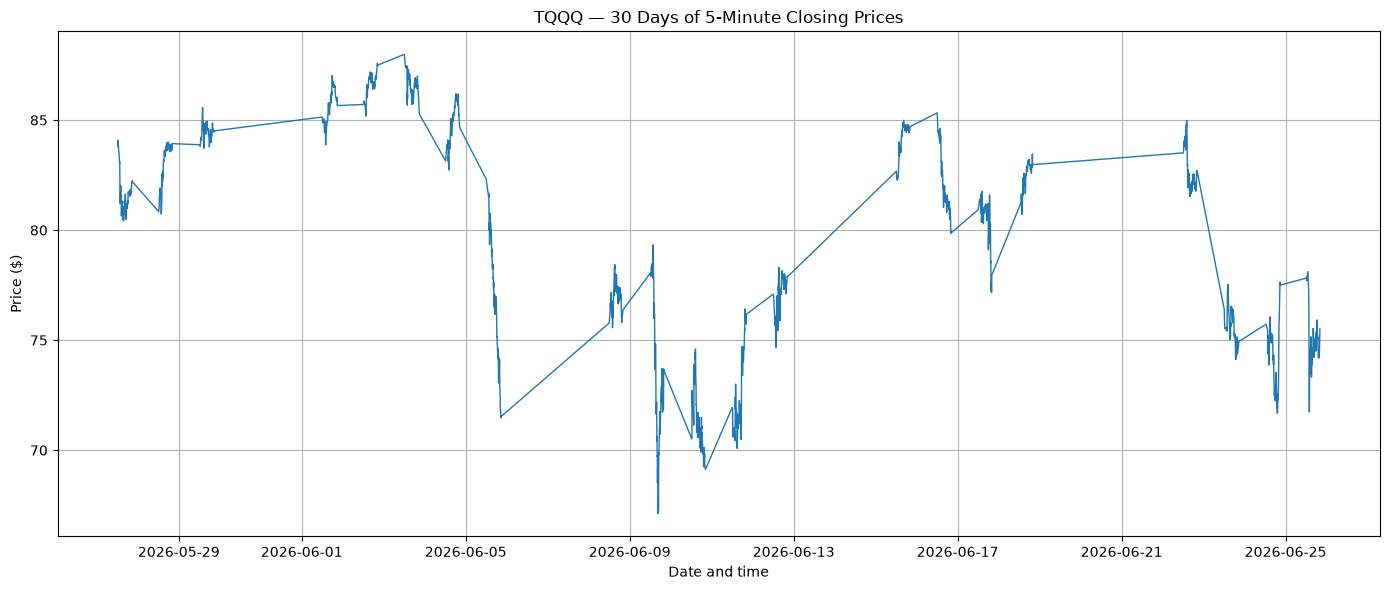

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    tqqq_5min.index,
    tqqq_5min["close"],
    linewidth=1
)

plt.title("TQQQ — 30 Days of 5-Minute Closing Prices")
plt.xlabel("Date and time")
plt.ylabel("Price ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

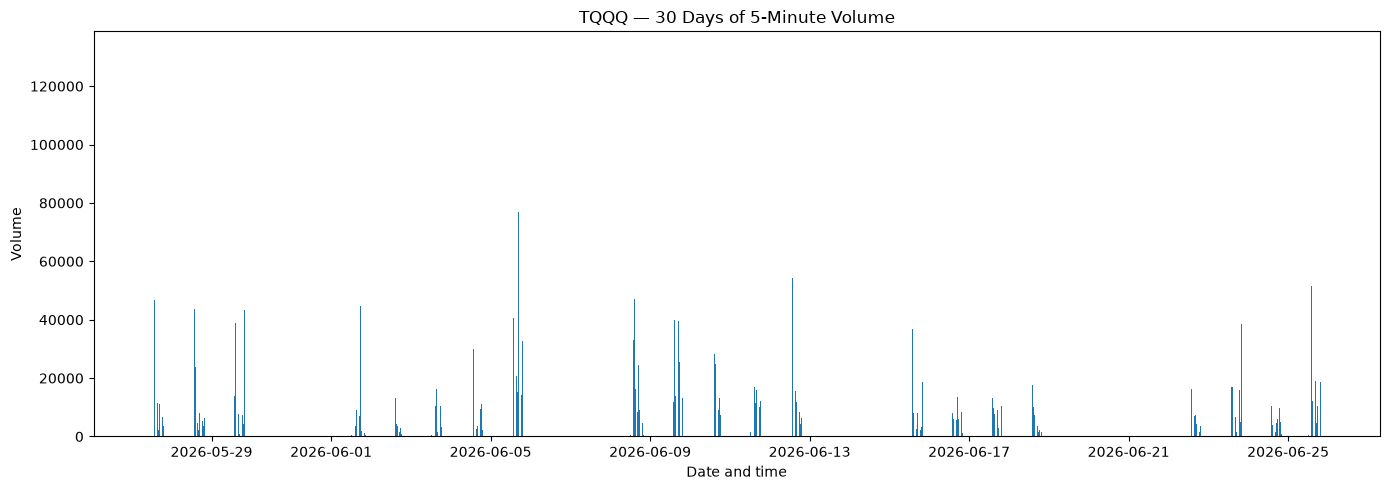

In [10]:
plt.figure(figsize=(14, 5))

plt.bar(
    tqqq_5min.index,
    tqqq_5min["volume"],
    width=0.002
)

plt.title("TQQQ — 30 Days of 5-Minute Volume")
plt.xlabel("Date and time")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

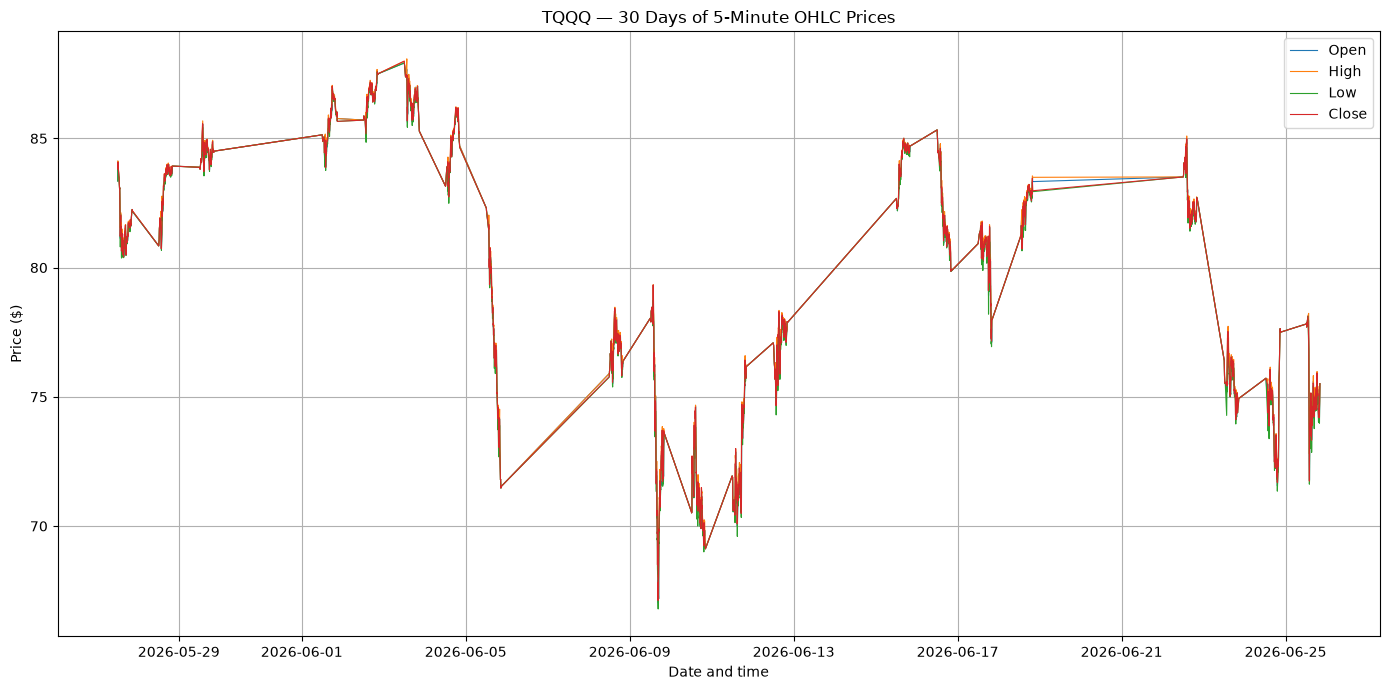

In [11]:
plt.figure(figsize=(14, 7))

plt.plot(tqqq_5min.index, tqqq_5min["open"], label="Open", linewidth=0.8)
plt.plot(tqqq_5min.index, tqqq_5min["high"], label="High", linewidth=0.8)
plt.plot(tqqq_5min.index, tqqq_5min["low"], label="Low", linewidth=0.8)
plt.plot(tqqq_5min.index, tqqq_5min["close"], label="Close", linewidth=0.8)

plt.title("TQQQ — 30 Days of 5-Minute OHLC Prices")
plt.xlabel("Date and time")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
display(
    tqqq_5min[
        ["open", "high", "low", "close", "volume"]
    ].tail(20)
)

,open,high,low,close,volume
timestamp,,,,,
2026-06-25 18:25:00+00:00,75.570,75.980,75.570,75.92,8806
2026-06-25 18:30:00+00:00,75.900,75.900,75.120,75.13,34762
2026-06-25 18:35:00+00:00,75.100,75.300,75.020,75.26,14790
2026-06-25 18:40:00+00:00,75.260,75.300,75.040,75.26,4989
2026-06-25 18:45:00+00:00,75.140,75.160,74.720,75.04,10704
2026-06-25 18:50:00+00:00,75.130,75.410,75.060,75.12,8015
2026-06-25 18:55:00+00:00,75.290,75.290,75.000,75.13,3134
2026-06-25 19:00:00+00:00,75.100,75.100,74.530,74.57,7765
2026-06-25 19:05:00+00:00,74.500,74.725,74.450,74.55,5136


In [15]:
try:
    stream.stop_ws()
    print("Previous stream stopped.")
except Exception:
    print("No active stream to stop.")

Previous stream stopped.


/var/folders/3q/j41srnrn1bxbfzf45m59yd5w0000gn/T/ipykernel_61546/3641745812.py:2: RuntimeWarning: coroutine 'Stream.stop_ws' was never awaited
  stream.stop_ws()


In [16]:
await stream.stop_ws()
print("Previous stream stopped.")


Previous stream stopped.


In [17]:
print("Thread alive:", stream_thread.is_alive())

Thread alive: False


In [18]:
%%writefile quote_ui.py

import importlib.util
import queue
import re
import threading
import tkinter as tk
from pathlib import Path
from tkinter import messagebox, ttk


CONNECTOR_FILENAME = (
    "anaconda_projects_"
    "b8df4445-ea07-4128-80ec-0f75bcd0d2a0_"
    "data_connector.py"
)


def load_connector_class():
    module_path = Path(__file__).parent / CONNECTOR_FILENAME

    spec = importlib.util.spec_from_file_location(
        "data_connector",
        module_path
    )

    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    return module.AlpacaDataConnector


AlpacaDataConnector = load_connector_class()


class RealTimeQuoteApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Alpaca Real-Time Quote Terminal")
        self.root.geometry("620x420")

        self.connector = AlpacaDataConnector()
        self.stream = None
        self.stream_thread = None
        self.message_queue = queue.Queue()

        self.symbol_var = tk.StringVar(value="TQQQ")
        self.current_symbol_var = tk.StringVar(value="No symbol selected")
        self.bid_var = tk.StringVar(value="—")
        self.ask_var = tk.StringVar(value="—")
        self.last_trade_var = tk.StringVar(value="—")
        self.status_var = tk.StringVar(value="Ready")

        self.build_ui()

        self.root.after(100, self.process_messages)
        self.root.protocol("WM_DELETE_WINDOW", self.close_app)

    def build_ui(self):
        main = ttk.Frame(self.root, padding=24)
        main.pack(fill="both", expand=True)

        ttk.Label(
            main,
            text="Alpaca Real-Time Quote Terminal",
            font=("Arial", 21, "bold")
        ).pack(pady=(0, 20))

        search = ttk.Frame(main)
        search.pack(pady=(0, 20))

        ttk.Label(
            search,
            text="Ticker:",
            font=("Arial", 13)
        ).pack(side="left")

        entry = ttk.Entry(
            search,
            textvariable=self.symbol_var,
            font=("Arial", 14),
            width=15
        )
        entry.pack(side="left", padx=10)
        entry.bind(
            "<Return>",
            lambda event: self.start_stream()
        )

        ttk.Button(
            search,
            text="Connect",
            command=self.start_stream
        ).pack(side="left")

        ttk.Label(
            main,
            textvariable=self.current_symbol_var,
            font=("Arial", 18, "bold")
        ).pack(pady=(0, 15))

        prices = ttk.Frame(main)
        prices.pack(fill="x", pady=10)

        self.add_metric(prices, "Current bid", self.bid_var, 0)
        self.add_metric(prices, "Current ask", self.ask_var, 1)
        self.add_metric(prices, "Last trade", self.last_trade_var, 2)

        for column in range(3):
            prices.columnconfigure(column, weight=1)

        ttk.Label(
            main,
            textvariable=self.status_var,
            font=("Arial", 12)
        ).pack(pady=20)

    def add_metric(self, parent, title, variable, column):
        frame = ttk.LabelFrame(
            parent,
            text=title,
            padding=15
        )
        frame.grid(
            row=0,
            column=column,
            padx=6,
            sticky="nsew"
        )

        ttk.Label(
            frame,
            textvariable=variable,
            font=("Arial", 18, "bold")
        ).pack()

    def validate_symbol(self):
        symbol = self.symbol_var.get().strip().upper()

        if not re.fullmatch(r"[A-Z0-9.\-]{1,15}", symbol):
            messagebox.showwarning(
                "Invalid ticker",
                "Enter a ticker such as AAPL, TSLA, or TQQQ."
            )
            return None

        return symbol

    def start_stream(self):
        symbol = self.validate_symbol()

        if symbol is None:
            return

        self.stop_stream()

        self.current_symbol_var.set(symbol)
        self.bid_var.set("Waiting...")
        self.ask_var.set("Waiting...")
        self.last_trade_var.set("Waiting...")
        self.status_var.set(f"Connecting to {symbol}...")

        new_stream = self.connector.create_quote_stream()

        async def quote_handler(quote):
            self.message_queue.put(
                (
                    "quote",
                    quote.bid_price,
                    quote.bid_size,
                    quote.ask_price,
                    quote.ask_size
                )
            )

        async def trade_handler(trade):
            self.message_queue.put(
                (
                    "trade",
                    trade.price,
                    trade.size
                )
            )

        new_stream.subscribe_quotes(
            quote_handler,
            symbol
        )

        new_stream.subscribe_trades(
            trade_handler,
            symbol
        )

        self.stream = new_stream

        self.stream_thread = threading.Thread(
            target=self.run_stream,
            args=(new_stream, symbol),
            daemon=True
        )

        self.stream_thread.start()

    def run_stream(self, stream, symbol):
        try:
            self.message_queue.put(
                ("status", f"Connected — waiting for {symbol} data")
            )

            stream.run()

        except Exception as error:
            self.message_queue.put(
                ("error", str(error))
            )

    def process_messages(self):
        try:
            while True:
                message = self.message_queue.get_nowait()
                message_type = message[0]

                if message_type == "quote":
                    _, bid, bid_size, ask, ask_size = message

                    self.bid_var.set(
                        f"${bid:,.2f}\nSize: {bid_size}"
                        if bid and bid > 0
                        else "Unavailable"
                    )

                    self.ask_var.set(
                        f"${ask:,.2f}\nSize: {ask_size}"
                        if ask and ask > 0
                        else "Unavailable"
                    )

                    self.status_var.set("Receiving live quote data")

                elif message_type == "trade":
                    _, price, size = message

                    self.last_trade_var.set(
                        f"${price:,.2f}\nSize: {size}"
                        if price and price > 0
                        else "Unavailable"
                    )

                elif message_type == "status":
                    self.status_var.set(message[1])

                elif message_type == "error":
                    self.status_var.set("Streaming error")
                    messagebox.showerror(
                        "Streaming error",
                        message[1]
                    )

        except queue.Empty:
            pass

        self.root.after(100, self.process_messages)

    def stop_stream(self):
        if self.stream is not None:
            try:
                self.stream.stop_ws()
            except Exception:
                pass

            self.stream = None

    def close_app(self):
        self.stop_stream()
        self.root.destroy()


root = tk.Tk()
app = RealTimeQuoteApp(root)
root.mainloop()

Writing quote_ui.py


In [1]:
import importlib.util
from pathlib import Path

module_path = Path(
    "anaconda_projects_b8df4445-ea07-4128-80ec-0f75bcd0d2a0_data_connector.py"
)

spec = importlib.util.spec_from_file_location(
    "data_connector",
    module_path
)

data_connector = importlib.util.module_from_spec(spec)
spec.loader.exec_module(data_connector)

AlpacaDataConnector = data_connector.AlpacaDataConnector

connector = AlpacaDataConnector()

tqqq_5min = connector.get_historical_data(
    symbol="TQQQ",
    days=30,
    bar_minutes=5
)

print("Number of rows:", len(tqqq_5min))
print("Columns:", list(tqqq_5min.columns))
display(tqqq_5min.head())

Number of rows: 1822
Columns: ['open', 'high', 'low', 'close', 'volume']


,open,high,low,close,volume
timestamp,,,,,
2026-05-27 12:15:00+00:00,83.35,83.82,83.35,83.82,1056
2026-05-27 12:20:00+00:00,84.12,84.13,83.96,83.96,840
2026-05-27 12:25:00+00:00,83.98,84.08,83.98,84.08,400
2026-05-27 12:50:00+00:00,83.57,83.57,83.57,83.57,280
2026-05-27 12:55:00+00:00,83.52,83.52,83.52,83.52,140
